- 챕터 4. word2vec 속도 개선
    - 이전 장에서의 CBOW 모델 구현에 몇 가지 문제가 있음, 가장 큰 문제는 말뭉치에 포함된 어휘수가 많아지면 계산량도 커진다는 점, 실제로 어휘 수가 어느 정도를 넘어서면 앞장의 CBOW 모델은 계산 시간이 너무 오래 걸림
    - 이번 장의 목표는 word2vec의 속도 개선, 첫 번째 개선으로는 Embedding 이라는 새로운 계층을 도입, 두 번재 개선으로는 네거티브 샘플링리아는 새로운 손실 함수 도입

- 4.1 word2vec 개선 1
    - 앞장에서는 아래 그림과 같은 CBOW 모델을 구현
    - 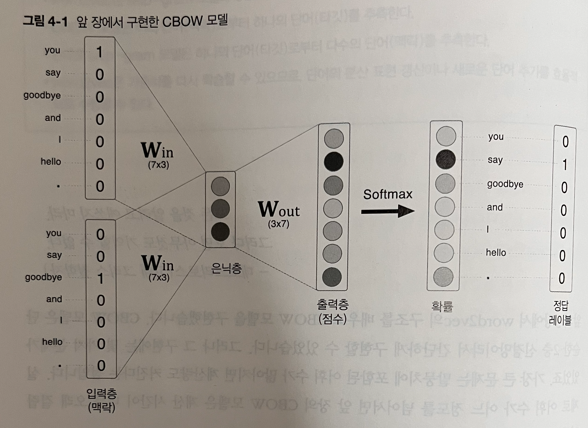
    - 위 그림과 같이 앞 장의 CBOW 모델은 단어 2개를 맥락으로 사용해, 이를 바탕으로 하나의 단어(타겟)를 추측, 이때 입력 측 가중치(W_in)와의 행렬 곱으로 은닉층이 계산되고, 다시 출력 측 가중치(W_out)와의 행렬 곱으로 각 단어의 점수를 구함, 그리고 이 점수에 소프트맥스 함수를 적용해 각 단어의 출현 확률을 얻고, 이 확률을 접답 레이블과 비교하여(정확히는 교차 엔트로피 오차를 적용) 손실을 구함
    - 앞 장에서는 맥락의 윈도우 크기를 1로 한정, 다시 말해 앞뒤 한 단어식만 사용한 것, 이번 장에서는 나중에 어떤 크기의 맥락도 다룰수 있도록 기능을 추가 진행
    - 위 그림의 CBOW 모델도 작은 말뭉치를 다룰때는 문제가 없음, 실제 위 그림에서 다루는 어휘수는 모두 7개인데 이정도는 문제없이 처리 가능, 그러나 거대한 말뭉치를 다루게 되면 몇가지 문제 발생, 그 문제점을 확인하기 위해 어휘가 100만개, 은닉층의 뉴런이 100개인 CBOW 모델을 생각해 보면, word2vec은 아래 그림 처럼 됨
    - 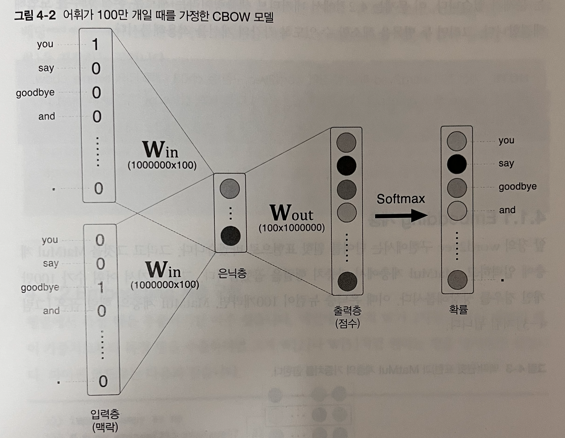
    - 위 그림에서 보듯, 입력층과 출력층에는 각 100만개의 뉴런이 존재, 이 수많은 뉴런 때문에 중간 계산에 많은 시간이 소요, 아래 2가지 계산이 병목이 됨
        - 입력층은 원핫 표현과 가중치 행렬 W_in의 곱 계산
        - 은닉층과 가중치 행렬 W_out의 곱 및 Softmax 계층의 계산
    - 첫번째는 입력층의 원핫 표현과 관련한 문제, 단어를 원핫 표현으로 다루기 때문에 어휘수가 많아지면 원핫 표현의 벡터 크기도 커지는 것, 예컨대 어휘가 100만개 라면 그 원핫 표현 하나만 해도 원소 수가 100만 개인 벡터가 됨, 이는 메모리가 낭비되는 문제 발생, 이 원핫 벡터와 가중치 행렬 W_in을 곱해야 하는 데 이것만으로 계산 자원을 상당히 사용
    - 두번째 문제는 은닉층 이후의 계산, 우선 은닉층과 가중치 행렬 W_out의 곱만 해도 계산량이 상당함, 그리고 Softmax 계층에서도 다루는 어휘가 많아짐에 따라 계산량이 증가하는 문제, 이 문제는 네거티브 샘플링이라는 새로운 손실 함수를 도ㅇ비하야 해결

- 4.1.1. Embedding 계층
    - 앞 장의 word2vec 구현에서는 단어를 원핫 표현으로 변환, 그리고 그것을 MatMul 계층에 입력, MatMul 계층에서 가중치 행렬을 곱함
    - 어휘 수가 100만개가 된다고 할때, 이때 은닉층의 뉴런이 100개라면 MatMul 계층의 행렬 곱은 아래 그림 처럼 됨
    - 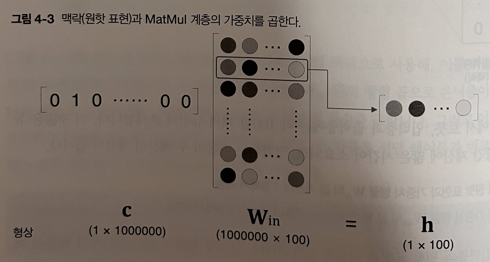
    - 위 그림 처럼 만약 100만개의 어휘를 담은 말뭉치가 있다면, 단어의 원핫 표현도 100만 차원이 됨, 그리고 이런 거대한 벡터와 가중치 행렬을 곱해야 함
    - 위 그림 에서 결과적으로 수행하는 일은 단지 행렬의 특정 행을 추출하는 것뿐, 따라사 원한 표현으로의 변환과 MatMul 계층의 행렬 곱 계산은 필요 없음
    - 그러면 가중치 매개변수로부터 단어ID에 해당하는 행(벡터)을 추출하는 계층을 만들수 있음, 그 계층을 Embedding 계층이라고 지칭, Embedding 계층에 단어 임베딩(분산 표현)을 저장하는 것
    - 자연어 처리 분야에서 단어의 밀집벡터 표현을 단어 임베딩 확은 단어의 분산 표현이라 함

- 4.1.2 Embedding 계층 구현
    - 행렬에서 특정행을 추출하는 것은 가중치 W가 2차원 넘파이 배열일때, 이 가중치로부터 특정 행을 추출하려면 그저 W[2], W[5] 처럼 원하는 행을 명시하면 끝

In [42]:
import numpy as np

W = np.arange(21).reshape(7, 3)
W

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14],
       [15, 16, 17],
       [18, 19, 20]])

In [43]:
W[2]

array([6, 7, 8])

In [44]:
W[5]

array([15, 16, 17])

In [45]:
idx = np.array([1, 0, 3, 0])
W[idx]

array([[ 3,  4,  5],
       [ 0,  1,  2],
       [ 9, 10, 11],
       [ 0,  1,  2]])

- 위 예에서는 인덱스 4개(1, 0, 3, 0번째)를 한 번에 추출, 이처럼 인수에 배열을 사용해도 여러행도 한꺼번에 추출 가능

In [46]:
# Embedding 계층의 forward() 메서드 구현
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

- 인스턴스 변수 params, grads 사용, 또한 인스턴스 변수 idx에는 추출하는 행의 엔덱스(단어 ID)
- 이어서 역전파(backward)를 새각해 보면, Embedding 계층의 순전파는 가중치 W의 특정행을 흘려보낸 것, 따라서 역전파에서는 앞 층(출력 측 층)으로 부터 전해진 기울기를 다음 층(입력 측 층)으로 그대로 흘려주면 됨, 다만 앞층으로붜 전해진 기울기를 가중치 기울기 dW의 특정 행(idx 번째 행)에 설정, 아래 그림 처럼 됨
- 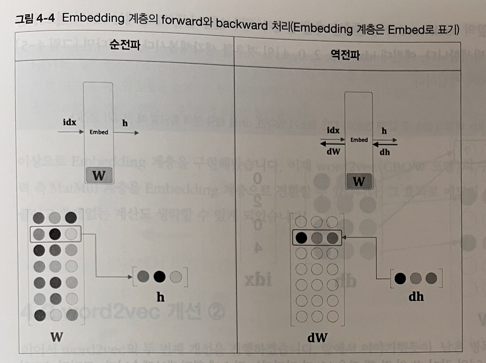
- 위 그림을 기초로 backward()를 구현

In [47]:
# Embedding 계층의 backward() 메서드 구현
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW = self.grads
        dW[...] = 0
        dW[self.idx] = dout     # 나쁜 방법, 추후에 수정 되는 지 확인 필요
        return None

- 위 코드는 가중치 기울기 dW를 꺼낸 다음(dW = self.grads), dW[...] = 0 문장에서 dW의 원소를 0으로 덮어씀(dW 자체를 0으로 설정하는 게 아니라, dW의 형상을 유지한 채, 그 원소들을 0으로 덮어씀), 그리고 앞 층에서 전해진 기울기 dout을 idx번째 행에 할당(dW[self.idx] = dout)
- 여기서는 가중치 W와 크기가 같은 행렬 dW를 만들고, dW의 특정 행에 기울기를 할당, 그러나 최종적으로 하고 싶은 일은 가중치 W를 갱신하는 것이므로 일부러 dW와 같은(W 와 같은 크기의) 행랼을 만들 필요는 없음, 이렇게 하지 않고 갱신하려는 행 번호(idx)와 그 기울기(dout)를 따로 저장해두면, 이 정보로부터 가중치(W)의 특정 행만 갱신할 수 있음, 다만 여기에서는 이미 구현해둔 갱신용 클래스(Optimizer)와 조합해 사용하는 것을 고려해 현재와 같이 구현

- 다만 위와 같은 backward() 구현에는 문제가 있음, idx의 원소가 중복될때 문제 발생, 예를 들어 idx가 [0, 2, 0, 4]일 경우 아래 그림과 같은 문제 발생
- 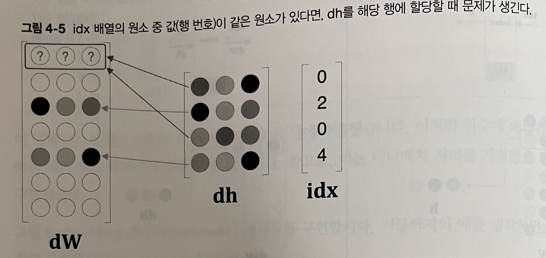
- 위 그림과 같이 dh의 각 행값을 idx가 가리키는 장소에 할당할때, dW의 0번째 행에 2개의 값이 할당되어, 먼저 쓰여진 값을 덮어 쓰게 됨
- 이 중복 문제를 해결하려면 할당이 아닌 더하기를 해야 함, 즉 dh의 각 행을 dW의 해당 행에 더해줌

In [48]:
# Embedding 계층의 backward() 메서드 수정
class Embedding:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None

    def forward(self, idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self, dout):
        dW, = self.grads
        dW[...] = 0
        # 아래 구문 수정
        # dW[self.idx] = dout     # 나쁜 방법, 추후에 수정 되는 지 확인 필요

        # # 위 구문을 아래 구문으로 대체
        # for i, word_id in enumerate(self.idx):
        #     dW[word_id] += dout[i]

        # 혹은
        np.add.at(dW, self.idx, dout)

        return None

- 여기서는 for문을 사용해 해당 인덱스에 기울기를 더함, 이것으로 idx의 중복 인덱스가 있더라고 올바르게 처리
- 참고로 for문대신 넘파이의 np.add.at()을 사용해도 됨, np.add.at(A, idx, B)는 B를 A의 IDX 번째 행에 더해줌
- 일반적으로 파이썬에서 for문보다 넘파이의 내장 메서드를 사용하는 것이 더 빠름, 넘파이의 메서드에서는 속도와 효율을 높여주는 최적화가 적용되어 있음

- 4.2 word2vec 개선
    - word2vec의 두번째 개선 진행, 남은 병목은 은닉층 이후의 처리(행렬 곱과 Softmax 계층의 계산), 네거티브 샘플링(부정적 샘플링)이라는 기법을 사용, Softmax 대신 네거티브 샘플링을 이용하면 어휘가 많아져도 계산량을 낮은 수준에서 일정하게 억제 가능

- 4.2.1 은닉층 이후 계산의 문제점
    - 은닉층 이후 계산의 문제점을 알아보기 위해 앞에서와 마찬가지로 어휘가 100만 개, 은닉층 뉴런이 100개 일때위 word2vec(CBOW 모델)을 예로 진행, 이때 word2vec이 수행하는 작업은 아래 그림과 같음
    - 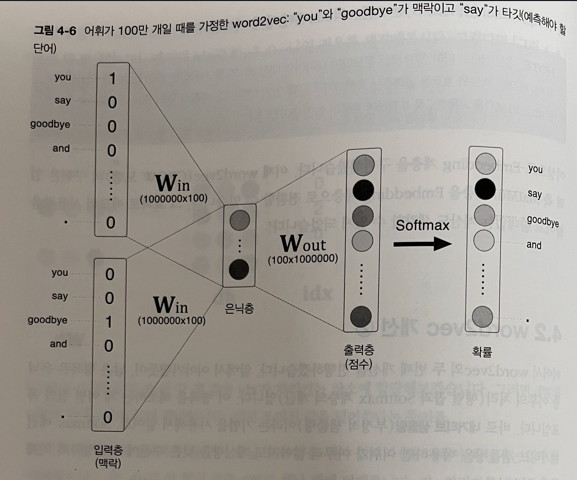
    - 위 그림에서 보듯 입력층과 출력층에는 뉴런이 각 100만 개씩 좀재, 앞 절에서는 Embedding 계층을 도입하여 입력층 계산에서의 낭비를 줄임, 남은 문제는 은닉층 이후의 처리, 은닉층 이후에서 계산이 오래 걸리는 곳은 다음의 두 부분
        - 은닉층의 뉴런과 가중치 행렬(W_out)의 곱
        - Softmax 계층의 계산
    - 첫 번째는 거대한 행렬을 곱하는 문제, 앞의 예에서는 은닉층의 벡터 크기가 100이고, 가중치의 행렬의 크기가 100x100만, 이렇게 큰 행렬의 곱을 계산하려면 시간이 오래 걸리고 메모리도 많이 필요, 또한 역전파 때도 같은 계산을 수행하기 때문에 이 행렬의 곱을 가볍게 만들 필요가 있음
    - 두 번째로 Softmax 에서도 같은 문제가 발생, 즉 어휘가 많아지면 Softmax의 계산량도 증가, 아래 Softmax 식 참조
    - 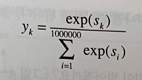
    - 위 식은 k번째 원소(단어)를 타겟으로 했을 때의 Softmax 계산식(점수의 각 원소는 s_1, s_2, ...) 이 식에서으 어휘 수를 100만개로 가정했기때문에 분모의 값을 얻으려면 exp 계산을 100만번 수행해여 함, 이 계산도 어휘 수에 비례해 증가하므로 Softmax를 대신할 가벼운 계산이 필요.

- 4.2.2 다중 분류에서 이진 분류로
    - 네커티브 샘플링 기법, 이 기법의 핵심 아이디어는 이진 분류에 있음, 더 정확하게는 다중 분류(혹은 다중 클래스 분류)를 이진 분류로 근사하는 것이 네거티브 샘플링을 이해라는데 중요한 포인트
    - 지금까지 다중 분류 문제를 다룸, 바로 앞에서의 예도 100만개의 단어중 옳은 단어 하나를 선책하는 문제, 그렇다면 이러한 문제를 이진 분류 문제로는 어떻게 다룰수 있을지, 더 정확하게는 다중 분류 문제를 어떻게 이진 분류 문제로 근사할 수 있을 지 확인 필요
    - 이진 분류틑 yes/no 로 답하는 문제를 다룸, 예컨데 이 숫자는 7입니까?, 이 동물은 고양이입니까? 타겟 단어는 say입니까 같은 문제는 모두 yes/no로 답할 수 있는 문제
    - 이제부터 다중 분류 문제를 이진 분류 방식으로 해결, 그러기 위해서는 yes/no로 답할 수 있는 질문을 생각해내야 함, 예컨데 맥락이 you와 goodbye일 때 타겟 단어는 say입니까? 라는 질문에 답하는 신경망을 생각해 내야 함. 이렇게 하면 출력층에는 뉴런을 하나만 준비하면 되므 출력층의 이 뉴런이 say의 점수를 출력, 이 때 CBOW 모델에서는 아래 그림과 같이 처리
    - 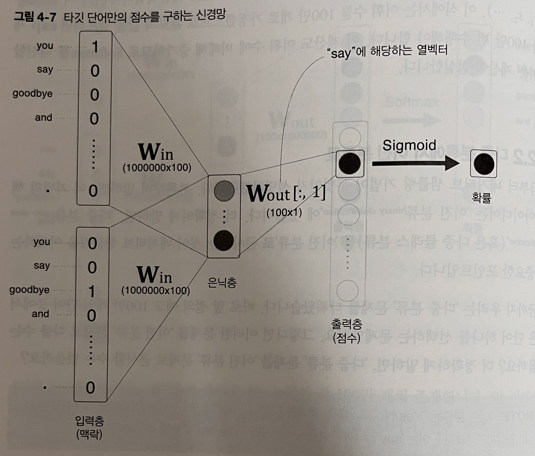
    - 위 그림에서 보듯 출력층의 뉴런은 하나뿐, 따라서 은닉층과 출력 측의 가중치 행렬의 내적은 say에 해당하는 열(단어 벡터)만을 추출하고, 그 추출된 벡터와 은닉층 뉴런과의 내적을 계산하면 끝, 아래 그림 참조
    - 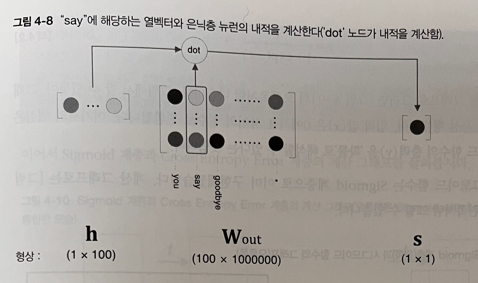
    - 위 그림처럼 출력 측의 가중치 W_out 에서는 각 단어 ID의 단어 벡터가 각각의 열로 저장, 이 예에서는 SAY에 해당하는 단어 벡터를 추출, 그리고 그 벡터와 은닉층 뉴런과의 내적을 구함, 이렇게 구산 값이 최종 점수
    - 이전까지의 출력츠에서는 모든 단어를 대상으로 계산을 수행, 하지만 여기서는 say라는 단어 하나에 주목하여 그 점수만을 계산하는 게 차이, 그리고 시그모이드 함수를 이용해 그 점수를 확률로 변환

- 4.2.3 시그모이드 함수와 교차 엔트로피 오차
    - 이진 분류 문제를 신경망으로 풀려면 점수에 시그모이드 함수를 적용해 확률로 변환하고, 손실을 구할때는 손실 함수로 교차 엔트로피 오차를 사용, 이 줄은 이진 분류 신경망에서 흔하게 사용되는 조합
    - 다중 분류의 경우, 출력층에서는 점수를 확률로 변환할때 소프트맥스 함수를 손실 함수로는 교차 엔트로피 오차를 이용, 이진 분류에서는 출력층에서는 시그모이드 함수를 손실 함수로는 교차 엔트로피 오차를 이용
    - 시그모이드 함수는 아래 식과 같이 사용.
    - 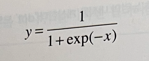
    - 의 식을 그래프로 그리면 아래 이미지의 오른쪽 처럼 나옴, 아래 그림에서 알 수 있듯이, 그래프틑 S자 형태의 곡선이며 입력 값(x)은 0에서 1 사이의 실수로 변환, 여기서의 핵심은 시그모이드 함수의 출력(y)을 확률로 해석할 수 있다는 것, 시그모이드 함수는 Simoid 계층으로 이미 구현, 계산 그래프로는 아래 그림의 왼쪽처럼 표현 가능
    - 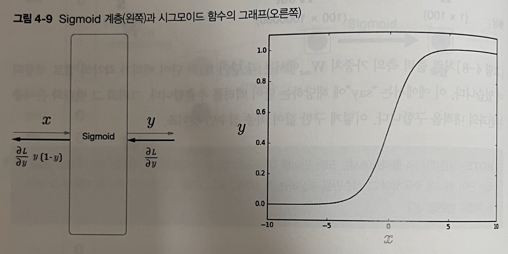
    - 시그모이드 함수를 적용해 확률 y를 얻으면 이 확률 y로부터 손실을 구함, 시그모이드 함수에 사용되는 손실 함수는 다중 분류 때 처럼 교차 엔트로피 오차, 교차 엔트로피 오차는 아래와 같이 작성 가능
    - 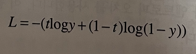
    - 여기에서 y는 시그모이드 함수의 출력이고, t는 정답 레이블, 이 정답 레이블의 값은 0 혹은 1 입니다. t가 1이면 정답은 yes 이고, 0이면 no, 다라서 t가 1dlaus -logy가 출력, 반대로 t가 0이면 -log(1-y)가 출력
    - 이진 분류와 다중 분류 모두 손실 함수로 교차 엔트로피 오차를 사용, 각각의 수식은 아래와 같이 좌/우 로 조금 다르지만 의미는 같음
    - 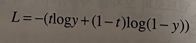 , 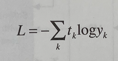
    - 다중 분류에서 출력층에 뉴런을 2개만 사용할 경우 이진 분류의 식인 위 식 중 좌측과 완전히 같아짐, 따라서 Softmax with Loss 계층의 코드를 조금만 손보면 Sigmoid with Loss 계층도 구현 가능
    - 이어서 Sigmoid 계층과 Cross Entropy Error 계층의 계산 그래프는 아래 그림과 같음
    - 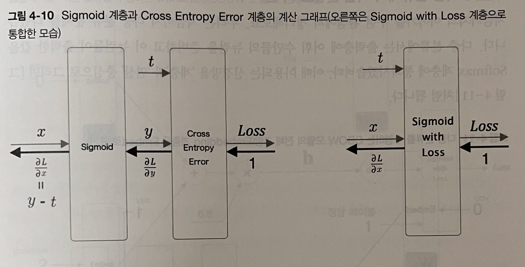
    - 위 그림에서 주목할 점은 역전파의 y-t값, 여기에서 y는 신경망이 출력한 확률이고 t는 정답 레이블, 그리고 y-t는 정확히 그 두 값의 차이, 정답 레이블이 1이라면 y가 1(100%)에 가까워질수록 오차가 줄어들게 됨, 반대로 y가 1로부터 멀어지게 되면 오차가 커짐, 그리고 그 오차가 앞 계층으로 흘러가므로, 오차가 크면 크게 학습하고 오차가 작으면 작게 학습 하게 됨
    - 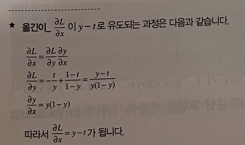
    - 시그모이드 함수와 교차 엔트로피 오차를 조합하여 역전파의 값이 y-t라는 깔끔한 결과를 도출함, 마찬가지로 소프트맥스 함수와 교차 엔트로피 오차의 조합, 또는 항등 함수와 2 제곱 오차의 조합에서도 역전파 시에 y-t가 전파

- 4.2.4 다중 분류에서 이진 분류로 변환
    - 다중 분류에서는 출력층에 어휘 수만큼의 뉴런을 준비하고 이 뉴런들이 출력한 값을 Softmax 계층에 통과 시킴, 이때 이용되는 신경망을 계층과 연산 중심으로 그리면 아래 그림과 같음
    - 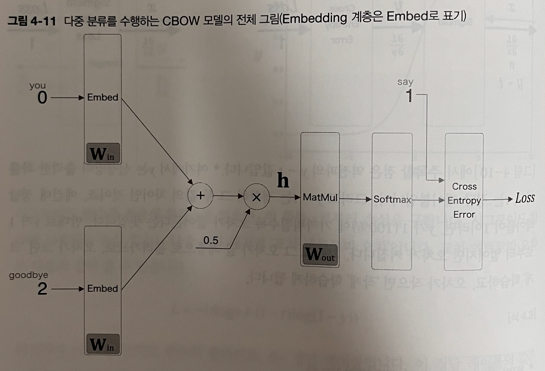
    - 위 그림은 맥락이 you와 goodbye이고 정답이 되는 타겟(예측해야 할 단어)이 say인 경우의 예(단어ID는 you가 0, say가 1, goodbye가 2라 가정), 또한 입력층에서는 각각에 대응하는 단어 ID의 분산 표현을 추출하기 위해 Enbedding계층을 사용
    - 위 그림의 신경망을 이진 분류 신경망으로 변환해보면 신경망의 구성은 아래 그림과 같음
    - 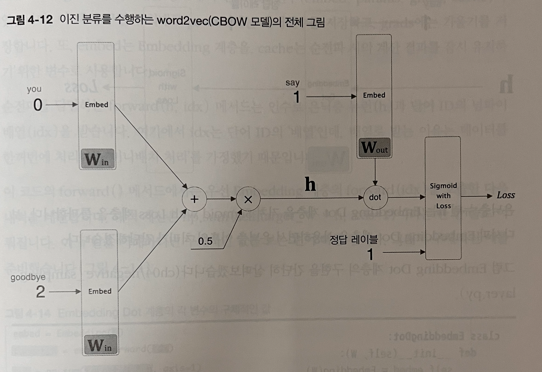
    - 위 그림에서는 은닉층 뉴런 h와 출력 측의 가중치 W_out 에서 단어 say에 해당하는 단어 벡터와의 내적을 계산, 그리고 그 출력을 Sigmoid with Loss 계층에 입력해 최종 손실을 얻음
    - 위 그림에서는 Sigmoid with Loss 계층에 정답 레이블로 1을 입력, 이는 현재 문제의 답이 Yes임을 의미, 답이 No라면 Sigmoid with Loss에 정답 레이블로 0을 입력해야 함
    - 위 그림의 후반부를 더 단순하게 만들어 본다면, Embedding Dot 계층을 도입 이 계층은 위 그림의 Embedding 계층과 dot연산(내적)의 처리를 합친 계층, 이 계층을 사용하면 위 그림의 후반부를 아래 그림 처럼 그릴 수 있음
    - 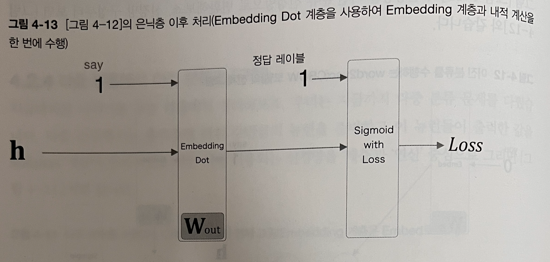

- 은닉층 뉴런 h는 Embedding Dot 계층을 거쳐 Sigmoid with Loss 계층을 통과, 위 그림과 같이 Embedding Dot 계층을 사용하면서 은닉층 이후의 처리가 간소해 짐

In [49]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.params
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache 
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W

        return dh

- EnbeddingDot 클래스에는 총 4개의 인스턴스 변수(embed, params, grads, cache)가 있음, params에는 매개변수를 저장하고, grads에는 기울기를 저장, 또 embed는 Embedding 계층을 cache는 순전파 시 계산 결과를 잠시 유지하기 위한 변수로 사용
- 순전파를 담당하는 forward(h, idx) 메서드는 인수로 은닉층 뉴런(h)과 단어ID의 넘파이 배열(idx)을 받음, 여기에서 idx는 단어ID의 배열, 배열로 받는 이유는 데이터를 한꺼번에 처리하는 미니배치 처리를 위함
- forward() 메서드에서는 우선 Embedding 계층의 forward(idx)를 호출한 다음 내적을 계산, 내적 계산은 np.sum(self.target_W * h, axis=1)이라는 한줄로 진행, 이 구현의 구체적인 값은 아래 그림 확인
- 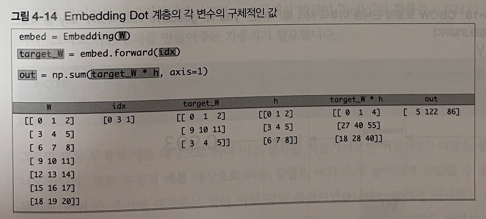
- 위 그림과 같이 적당한 W와 h, 그리고 idx를 준비, 여리에서 idx가 [0, 3, 1]인데, 이는 3개의 데이터를 미니배치로 한 번에 처리하는 예를 뜻함, idx가 [0, 3, 1]이므로 target_W는 W의 0번, 3번, 1번째의 행을 추출한 결과, 그리고 target_W * h는 각 원소의 곱을 계산(넘파이 뱌열의 * 연산은 원소별 곱을 수행), 그리고 이 결과를 행마다(axis=1) 전부 더해 최종 결롸 out를 얻음

- 4.2.5 네거티브 샘플링
    - 다중 분류에서 이진 분류로의 변환 진행, 현재까지는 긍정적인 예(정답)에 대해서만 학습 진행, 부정적인 예(오답)를 입력하면 어떤 결과 가 나올지 확인 필요
    - 맥락이 you와 goodbye이고 정답 타겟이 say인 경우, 긍정적인 예인 say만을 대상으로 이진 분류 진행, 여기에 좋은 가중치가 준비되어 있다면 Sigmoid 계층의 출력(확률)은 1에 가까울 것, 이때의 처리를 계산 그래프로는 아래 그림처럼 그릴 수 있음
    - 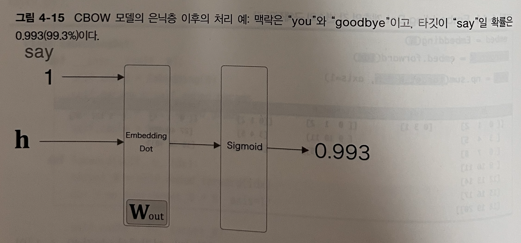
    - 현재까지는 신경망에서 긍적적 예인 say에 대해서만 학습, 그러나 부적적 예(say 이외의 단어)에 대해서는 학습이 진행되지 않음
    - 긍적적 예(say)에 대해서는 Sigmoid 계층의 출력을 1에 가깝게 만들고, 부정적 예(say 이외의 단어)에 대해서는 Sigmoid 계층의 출력을 0에 가깝게 만다는 것이 필요, 그림으로는 아래와 같음
    - 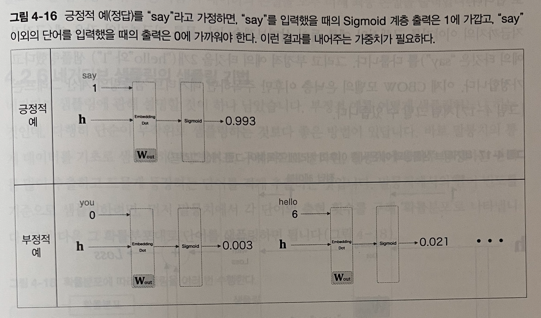
    - 맥락이 you와 goodbye일때 타겟이 hello일 확률(틀린 단어일 확룰)은 낮은 값이어야 바람직함, 위 그림에서는 타겟이 hello일 확률은 0.021(2.1%), 이런 결과를 만들어 주는 가중치가 필요
    - 다중 분류 문제를 이진 분류로 다루려면 정답(긍정적 예)과 오답(부정적 예) 각각에 대해 바르게 이진 분류 할수 이어야 함, 따라서 긍정적 예와 부정적 예 모두를 대상으로 문제를 생각해야 함
    - 부정적 예에 대해서도 학습이 필요하지만 모든 부정적 예를 대상으로 학습하기에는 어휘수가 늘어났을때 처리량이 너무 많아지는 문제 발생, 적은 수의 부정적 예를 샘플링해 사용할 필요가 있음, 이것이 바로 네거티브 샘플링 기법
    - 정리하면 네거티브 샘플링 기법은 긍정적 예를 타겟으로 한 경우의 손실을 구함, 그와 동시에 부정적 예를 몇 개 샘플링(선별)하여, 그 부정적 예에 대해서도 마찬가지로 손실을 구함, 그리고 각각의 데이터(긍정적 예와 샘플링된 부정적 예)의 손실을 더한 값을 최종 손실로 함
    - 긍정적 예의 타겟 say, 부정적 예의 타겟을 hello, I로 샘플링 할때, CBOW 모델의 은닉층 이후만 주목하면 네거티브 샘플링의 계산 그래프는 아래 그림과 같음
    - 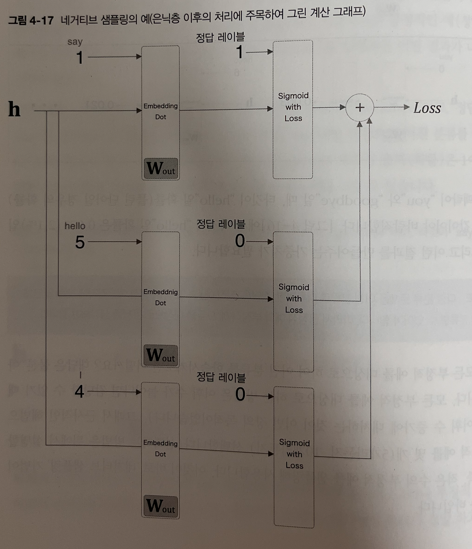
    - 위 그림에서 주의할 부분은 긍정적 예와 부정적 예를 다루는 방식, 긍적적 예(say)에 대해서는 지금까지 처럼 Sigmoid with Loss 계층에 정답 레이블로 1을 입력, 한편 부정적 예(hello, I)에 대해서는 Sigmoid with Loss 계층에 정답 레이블로 0을 입력, 그런 다음 각 데이터의 손실을 모두 더해 최종 손실을 출력

- 4.2.6 네거티브 샘플링의 샘플링 기법
    - 네거티브 샘플링에서 부적적 예를 어떻게 샘플링하는 지 확인, 단순하게 무작위로 샘플링 하는 것보다, 말뭉치의 동계 데이터를 기초로 샘플링 하는 방법, 구체적으로 말하면 말뭉치에서 자주 등장하는 던어를 많이 추출하고 드물레 등장하는 단어를 적게 추출하는 것, 말뭉치에서의 단어 빈도를 기준으로 샘플링하려면, 먼저 말뭉치에서 각 단어의 출현 횟수를 구해 확률분포로 나타냄, 그런 다음 확률분포대로 단어를 샘플링하면 아래 그림과 같음
    - 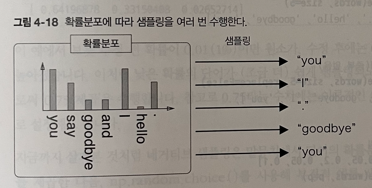
    - 말 뭉치에서의 단어별 출현 횟수를 바탕으로 확률분포를 구한 다음, 그 확률분포에 따라서 샘플링을 수행하기만 하면 됨, 확률분포대로 샘플링하면서 말뭉치에서 자주 등장하는 단어는 선택될 가능성이 높음, 같은 이유로 희소한 단어는 선택되기가 어려움
    - 네거티브 샘플링에서는 부정적 예를 가능한 한 많이 다루는 것이 좋지먼, 계산량 문제 때문에 적은 수로 한정해야 함, 다만 이때 우연히 희소한 단어만 선택이 될 경우, 결과가 나빠지게 됨, 흔한 단어를 잘 처리하는 편이 좋은 결과로 이어질 수 있음

In [50]:
import numpy as np

# 0에서 9까지의 숫자 중 하나를 무작위로 샘플링
random_val1 = np.random.choice(10)
random_val2 = np.random.choice(10)

print(random_val1)
print(random_val2)

# words에서 하나만 무작위로 샘플링
words = ["you", "say", "goodbye", "I", "hello", "."]
random_word = np.random.choice(words)

print(random_word)

# 5개만 무작위로 샘플링(중복 허용)
random_word1 = np.random.choice(words, size=5)
print(random_word1)

# 5개만 무작위로 셈플링(중복 없음)
random_word2 = np.random.choice(words, size=5, replace=False)
print(random_word2)

# 확률 분포에 따라 샘플링
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
random_word_p = np.random.choice(words, p=p)

print(random_word_p)

3
8
you
['goodbye' 'goodbye' '.' 'goodbye' 'you']
['you' 'goodbye' '.' 'say' 'I']
I


- 위 코드에서 보듯 np.random.choice()는 무작위 샘플링 용도로 이용, 이때 인수로 size를 지정하면 샘플링을 size만큼 수행, 또한 인수에 replace=False를 지정하면 샘플링 시 중복을 없애줌, 그리고 인수 p에 확률분포를 담은 리스트를 지정하면 그 확률분포대로 샘플링 진행
- word2vec의 네거티브 샘플링에서는 앞의 확률분포에서 한 가지를 수정하라고 권고, 아래 그림의 식 처럼 기본 확률분포에 0.75를 제곱하는 것
- 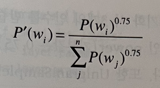
- P(w_i)는 i번째 단어의 확률을 뜻함, 위 식은 단순히 원래 확률분포의 각 요소를 0.75제곱 함, 다만 수정 후에도 확률의 총합은 1이 되어야 하기 때문에 분모로는 수정 후 확률 분포의 총합이 필요
- 위 식처럼 수정하는 이유는 출현 확률이 낮은 단어를 버리지 않기 위함, 더 정확하게 말하면 0.75제곱을 함으로써, 원래 확률이 낮은 단어의 확률을 살짝 높일 수 있음

In [51]:
p = [0.7, 0.29, 0.01]
new_p = np.pow(p, 0.75)
new_p /= np.sum(new_p)
print(new_p)

[0.64196878 0.33150408 0.02652714]


- 위 코드에서 보듯 수정 전 확률이 0.01(1%)이던 원소가 수정 후에는 0.0265...(약 2.65%)로 높아짐, 이처럼 낮은 확률의 단어가 조금 더 쉽게 샘플링되도록 하기 위한 구제 조치로 0.75제곱을 수행, 다만 0.75라는 수치에는 이론적인 의미가 없음, 다른 값도 가능
- 지금까지 진행은 말뭉치에서 단어의 확률분포를 만들고, 다시 0.75를 제곱한 다음np.random.choice()를 사용해 부정적 예를 샘플링

In [52]:
import collections
from common.np import *

class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1
        
        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy)로 계산할 때는 속도를 우선
            # 부정적 예에 타겟이 포함될 수 있음
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)
            
        return negative_sample

corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3])
power = 0.75
sample_size = 2

sampler = UnigramSampler(corpus, power, sample_size)
target = np.array([1, 3, 0])
negative_sample = sampler.get_negative_sample(target)
print(negative_sample)

[[3 2]
 [1 0]
 [1 2]]


- 위 코드에서는 긍정적 예로 [1, 3, 0]이라는 3개의 데이터를 미니배치로 처리, 이 각각의 데이터에 대해서 부적적 예를 2개씩 샘플링, 이 예에서는 첫 번째 데이터에 대한 부정적 예는 [4 3], 두번째는 [1 2], 세번째는 [2 3]이 선택(랜덤값으로 실행시 마디 결과는 변경)

In [53]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 정답 데이터가 원-핫 벡터라면 인덱스로 변환 (기존 로직 유지)
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]

    # [수정] Sigmoid 출력을 위한 이진 크로스 엔트로피 계산
    # y가 (batch_size, 2) 형태([1-p, p])로 들어올 때를 가정합니다.
    delta = 1e-7
    return -np.sum(np.log(y[np.arange(batch_size), t] + delta)) / batch_size

class SigmoidWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        #self.y = 1 / (1 + np.exp(-x))

        #self.y = np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))
        # [수정안] 복잡한 np.where 대신 np.clip을 사용하세요.
        # x값이 -500보다 작으면 -500으로, 500보다 크면 500으로 고정합니다.
        # exp(500)은 오버플로우가 나지 않으면서 충분히 1에 가까운 결과를 냅니다.
        safe_x = np.clip(x, -15, 15)
        
        self.y = 1 / (1 + np.exp(-safe_x))

        #self.loss = cross_entropy_error(np.c_[1 - self.y, self.y], self.t)

        # 3. cross_entropy_error 함수에 전달할 형태 구성
        # 이진 분류를 다중 분류 함수 형식(batch, 2)에 맞게 변형
        # [1-y, y] -> 첫 번째 열은 0일 확률, 두 번째 열은 1일 확률
        y_2d = np.c_[1 - self.y, self.y]
        
        self.loss = cross_entropy_error(y_2d, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = (self.y - self.t) * dout / batch_size

        return dx

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]
        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads
    
    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 긍정적 예 순전파
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 부정적 예 순전파
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh

- 초기화 매서드(__init__)의  인수로는 출력 측 가중치를 나타내는 W, 말뭉치(단어ID의 리스트)를 뜻하는 corpus, 확훟분포에 제곱할 값인 power, 그리고 부정적 예의 샘플링 횟수인 sample_size
- 위 코드에서는 UnigramSampler 클래스를 생성하여 인스턴스 변수인 sampler로 저장, 또한 부정적 예의 샘플링 횟수는 인스턴스 변수인 sample_size 에 저장
- 인스턴스 변수인 loss_layers와 embed_dot_layers에는 원하는 계층을 리스트로 보롼, 이때 이 두 리스트에는 sample_size + 1개의 계층을 생성하는데, 부정적 예를 다루는 계층이 sample_size개 만큼이고, 여기에 더해 긍정적 예를 다루는 계층이 하나 더 필요하기 때문, 정확히는 0번째 계층, 즉 loss_layers[0]과 embed_dot_layers[0]이 긍정적 예를 다루는 계층, 그런 다음 이 계층에서 사용하는 매개변수와 기울기를 각각 배열로 저장

- forward(h, target) 메서드가 받은 인수는 은닉층 뉴런 h와 긍정적 예의 티겟을 뜻하는 targe, 이 메서드에서 우선 self.sampler를 이용해 부정적 예를 샘플링하여 negative_sample에 저장, 그런 다음 긍정적 예와 부정적 예 각각의 데이터에 대해서 순전파를 수행해 그 손실들을 더함, 구체적으로 Embedding Dot 계층의 forward 점수를 구하고 이어서 이 점수와 레이블을 Sigmoid with Loss 계층으로 흘려 손실을 구함, 여기서는 긍정적 예의 정답 레이블(correct_label)은 1이고, 부정적 예의 정답 레이블(negative_label)은 0임을 주의

- 역전파는 순전파때의 역순으로 각 계층의 backward()를 호출하기만 하면 됨, 은닉층의 뉴런은 순전파 시에 여러개로 복사됨, 이는 Repeat 노드에 해당

- 4.3 개선판 word3vec 학습
    - 기존 word2vec을 개선 진행, 먼저 Embedding 계층을 설명하고, 이어서 네거티브 샘플링 기법도 설명, 그리고 이 두가지를 추가함. 이러한 개선을 신경망 구현에 적용 필요

In [54]:
class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 가중치 초기화
        W_in = 0.01 * np.random.randn(V, H).astype(np.float32)
        W_out = 0.01 * np.random.randn(V, H).astype(np.float32)

        # 계층 생성
        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)     # Embedding 계층 사용
            self.in_layers.append(layer)
        
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 모든 가중치와 기울기를 배열에 모음
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 인스턴스 변수에 단어의 분산 표현을 저장
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        
        return None

- __init__(), 이 초기화 메서드는 4개의 인수를 받은 , vocab_size는 어휘 수, hidden_size는 은닉층의 뉴런 수, corpus는 단어 ID 목록, 그리고 맥락의 크기(주변 단어 중 몇 개나 맥락으로 포하시킬지)를 window_size로 지정, window_size가 2이면 타겟 단어의 좌우 2개씩 총 4개 단어가 맥락이 됨
- SimpleCBOW 클래스(개선 전)에서는 입력 측의 가중치와 출력 측의 가중치으 향상이 달라서 출력측의 가중치에서는 단어 벡터가 열 방향으로 배치, 한편 CBOW 클래스의 출력 측 가중치는 입력 측 가중치와 같은 형상으로, 단어 벡터가 행 방향으로 배치, 그 이유는 NegativeSamplingLoss 클래스에서 Embedding 계층을 사용하기 때문
- 가중치 초기화가 끝나면, 이어서 계층을 생성, Embedding 계층을 2 * window_size 개 작성하여 인스턴스 변수인 in_layers에 배열로 보관, 그런 다음 Negative Sampling Loss 계층을 생성
- 계층을 다 생성 했으면 이 신경망에서 사용하는 모든 매개변수와 기울기를 인스턴스 변수인 params와 grads에 모음, 또한 나중에 단어의 분산 표현에 접근할 수 있도록 인스턴스 변수인 word_vecs에 가중치 W_in을 할당

- 위 코드는 각 계층의 순전파(혹은 역전파)를 적절한 순서로 호출, SimpleCBOW 클래스를 자연스업게 확장, 단 forward(contexts, target) 메서드가 인수를 받는 맥락과 타겟이 단어 ID 라는 점이 다름, 구체적인 예를 아래 그림 확인
- 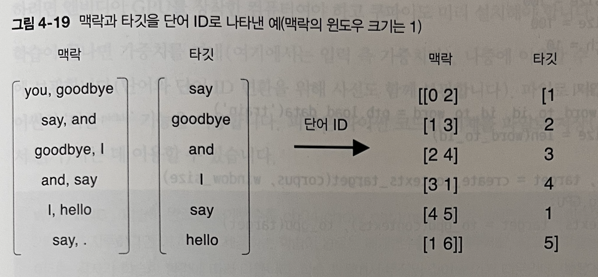
- 위 그림의 오른쪽에 보이는 단어ID의 배열이 contexts와 target의 예, contexts는 2차원 배열, target는 1차원 배열, 이러한 데이터가 forward(contexts, target)에 입력

In [55]:
isGPU = False

In [56]:
import subprocess

def check_nvidia_gpu():
    try:
        import cupy as np
        # 설치된 CuPy 버전 확인
        print(f"CuPy 버전: {np.__version__}")
        isGPU = True
    except(Exception, FileNotFoundError):
        print('not GPU Mode\n')
        import numpy as np



In [57]:
check_nvidia_gpu()


CuPy 버전: 13.6.0


In [58]:
if isGPU == True:
    def to_gpu(x):
        if type(x) == np.ndarray:
            return x
        return np.asarray(x)
else:
    def to_cpu(x):
        if type(x) == np.ndarray:
            return x
        return np.asnumpy(x)

In [64]:
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from cbow import CBOW
from common.util import create_contexts_target
from dataset import ptb

# 하이퍼파람터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 2

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data("train")
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)

if isGPU == True:
    contexts, target = to_gpu(contexts), to_gpu(target)

# 모델 등 생성
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 추후에 사용할 수 있도록 필요한 데이터 저장
word_vecs = model.word_vecs
if isGPU == True:
    word_vecs = to_cpu(word_vecs)

params = {}
params["word_vecs"] = word_vecs.astype(np.float16)
params["word_to_id"] = word_to_id
params["id_to_word"] = id_to_word
pkl_file = "cbow_param.pkl"
with open(pkl_file, "wb") as f:
    pickle.dump(params, f, -1)

| 에폭 1 |  반복 1 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 1[s] | 손실 4.16


KeyboardInterrupt: 

In [62]:
import sys
sys.path.append("..")
from common.util import most_similar
import pickle

pkl_file = "cbow_param.pkl"

with open(pkl_file, "rb") as f:
    params = pickle.load(f)
    word_vecs = params["word_vecs"]
    word_to_id = params["word_to_id"]
    id_to_word = params["id_to_word"]

querys = ["you", "year", "car", "toyota"]
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


[query] you
 i: 0.9970703125
 if: 0.99609375
 they: 0.99609375
 what: 0.99609375
 not: 0.99609375

[query] year
 loss: 0.99072265625
 from: 0.990234375
 about: 0.990234375
 year-earlier: 0.990234375
 fiscal: 0.9892578125

[query] car
 set: 0.998046875
 through: 0.99755859375
 corporate: 0.99755859375
 letter: 0.99755859375
 despite: 0.99755859375

[query] toyota
 car: 0.994140625
 similar: 0.994140625
 proposed: 0.994140625
 managed: 0.994140625
 distribution: 0.994140625


- 위 코드의 결과를 보면 you를 물으니 비슷한 단어로 인칭대명사 i(=I)와 we 등이 나옴, year에 대해서는month와 week 같은 기간을 뜻하는 같은 성격의 단어들이 나옴, 그리고 toyota에 대해서는 ford, mazda, nissan같은 자동차 메이커가 나옴, 결과를 보면 CBOW 모델로 획득한 단어의 분산 표현은 제법 괜찮은 특성을 지님
- word2vec으로 얻은 단어의 분산 표현은 비슷한 단어를 가까이 모을 뿐 아니라, 더 복잡한 패턴을 파악하는 것으로 알려져 있음, 대표적인 예가 king - man + woman = queen 으로 유명한 유추 문제(비유 문제), 더 정확하게 말하자면, word2vec의 단어의 분산 표현을 사용하면 유추 문제를 벡터의 덧셈과 뺄셈으로 풀 수 있다는 뜻
- 실제로 유추 문제를 풀려면 아래 그림 처럼 단어 벡터 공간에서 man -> woman 벡터와 king -> ? 벡터가 가능한 한 가까워지는 단어를 찾음
- 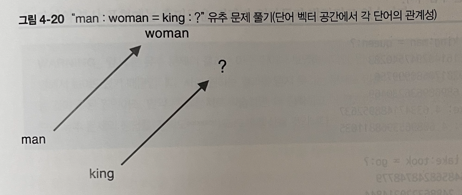
- 단어 man으 분산 표현(단어 벡터)을 vec("man") 이라고 표현 하면 위 그림에서 얻고 싶은 관계를 수식으로 나타내면 vec("woman") - vec("man") = vec(?) - vec("king")이 됨, 즉 우리가 풀어야 하는 문제는 vec("king") + vec("woman") - vec("man") = vec(?) 라는 벡터에 가장 가까운 단어 벡터를 구하는 일이 됨

- 4.4 word2vec 남은 주제
    - 4.4.1 word2vec을 사용한 애플리케이션의 예
        - word2vec으로 얻은 단어의 분산 표현은 비슷한 단어를 찾는 용도로 이용 가능, 그러나 단어 분산 표현의 장접은 그것만이 아님, 자연어 처리 분야에서 단어의 분산 표현이 중요한 이유는 전이 학습 임, 진이 학습은 한 분야에서 배운 지식을 다른 분야에도 적용하는 기법
        - 자연어 문제를 풀 때 wordwvec의 단어 분산 표현을 처음부터 학습하는 일은 거의 없음, 그 대신 먼저 큰 말뭉치로 학습을 끝난 후, 그 분산 표현을 각자의 작업에 이용하는 것, 예컨데 텍스트 분류, 문서 클러스터링, 품사 태그 달기, 감정 분석 등 자연어 처리 작업이라면 가장 먼저 단어를 벡터로 변환하는 작업을 해야 하는 데, 이때 학습을 미리 끝낸 단어의 분산 표현을 이용 가능, 그리고 이 학습된 분산 표현이 방금 언급한 자연어 처리 작업 대부분에 휼륭하게 적용
        - 단어의 분산 표현은 단어를 고정 길이 벡터로 변환한다는 장점도 있음, 문장(단어의 흐름)도 단어의 분산 표현을 사용하여 고정 길이 벡터로 변환 가능, 문장을 고정 길이 벡터로 변환하는 방법은 활발하게 연구되고 있는 데 가장 간단한 방법은 문장의 각 단어를 분산 표현으로 변화하고 그 합을 구하는 것, 이를 bag-of-words라 하여 단어의 순서를 고려하지 않는 모델, 또한 다음장에서 진행할 순한 신경망(RNN)을 사용하면 더 좋은 방법으로 word2vec의 단어 분산 표현을 이용하면서 문장을 고정 길이 벡터로 변환 가능
        - 단어의 문장을 고정 길이 벡터로 변화할 수 있다는 점은 매우 중요, 자연어를 벡터로 변환 할수 있다면 일반적인 머신러닝 기법(신경망이나 SVM)을 적용할 수 있음, 이를 아래 그림처럼 표현 가능
        - 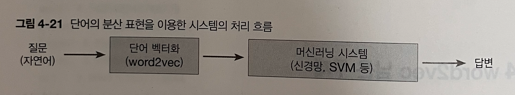
        - 위 그림에서 보듯 자연어로 쓰여진 질문은 고정 길이 벡터로 변환할 수 있다면, 그 벡터를 다른 머신 러닝 시스템의 입력으로 사용 가능, 자연어를 벡터로 변환함으로써 일반적인 머신러닝 시스템의 틀에서 원하는 답을 출력하는 것(또 학습하는 것)이 가능
        - 위 그림의 파이프라인에서 단어의 분산 표현 학습과 머신러닝 시스템의 학습은 서로 다른 데이터셋을 사용해 개별적으로 수행하는 것이 일반저그 예컨데 단어의 분산 표현은 범용 말뭉치를 사용해 미리 학습하고 현재 직면한 문제에 관련하여 수집한 데이터를 가지고 머신 러닝 시스템(SVM 등)을 학습시킴, 다만 직면한 문제의 학습 데이터가 아주 많다면 단어의 분산 표현과 머신러닝 시스템 학습 모두 처음부터 수행하는 방안도 고려
        - 구체적인 예를 보면서 단어의 분산 표현의 사용법 확인, 사용자가 1억명 이상인 스마트폰의 앱을 개발, 운영한다고 가정한다면 회사가 감당하기 어려울 정도의 메일이 사용자로부터 매일 전달 되므 그중에는 호의적인 의견과 불만의 의경이 있음
        - 메일을 자동으로 분류하는 시스템을 만들려고 한다면 아래 그림과 같이 메일의 내용을 보고 사용자의 감정을 3단계로 뷴류 가능 한지 확인해야 함
        - 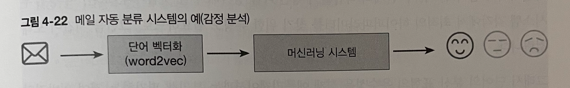
        - 사용자의 감정을 정확하게 분류할 수 있다면 불만을 가진 사용자의 메일부터 순서대로 처리 가능
        - 메일 자동 분류 시스테을 만들려면, 우선 데이터(메일)을 수집해야 함, 지금 예에서는 사용자가 보낸 메일을 모으고, 모은 메일들에 수동으로 레이블을 붙임, 예컨데 3단계의 감정을 나타내는 레이블(긍정, 중립, 부정)을 붙임, 레이블링 작업이 끝나면 학습된 word2vec을 이용해 메일을 벡터로 변환, 그런 다음 감정 분석을 수행하는 어떤 분류 시스템(SVM이나 신경망)에 벡터화 된 메일과 감정 레이블을 입력하여 학습을 수행
        - 이 예처럼 자연어를 다루는 문제는 단어의 분산 표현이라는 방법으로 벡터화 할 수 있음

- 4.4.2 단어 벡터 평가 방법
    - word2vec을 통해 단어의 분산 표현을 얻음, 그러면 그 분산 표현을 어떻게 평가하는 방법에 대한 설명
    - 단어의 분산 표현은 앞 절에서 본 감정 분선 예처럼, 현실적으로는 특정한 애플리케이션에서 사용되는 것이 대부분, 그렇다면 우리가 궁극적으로 원하는 것은 정확도 높은 시스템, 여기서 생각해봐야 하는 것은 그 시스템(예컨데 감정 분석 시스템)은 여러 시스템, 단어의 분산 표련을 만드는 시스템(word2vec)과 특정 문제에 대해 분류를 수행하는 시스템(예컨데 감정을 분류하는 SVM 등) 등
    - 단어의 분산 표현을 만드는 시스템과 분류하는 시스템의 학습은 따로 수행 가능, 그 경우, 단어의 분산 펴현의 차원 수가 최종 정확도에 어떤 영향을 주는지를 조사하려면, 우선 단어의 분산 표현을 학습하고 그 분산 표현을 사용하여 또 하나의 머신러닝 시스템을 학습시켜야 함, 즉 두 단계의 학습으 수행한 다음 평가가 필요, 또한 이 경우 두 시스템 각각에서 최적의 하이퍼파라미터를 찾기 위한 튜닝도 필요하므로 시간이 오래 걸림
    - 그래서 단어의 분산 표현의 우수성을 실제 애플리케이션과는 분리해 평가하는 것이 일반적, 예를 들어 유사도를 0에서 10사이로 점수화한다면 cat과 animal의 유사도는 8점, cat과 car의 우사도는 2점과 같이 사람이 단어 사이의 유사한 정도를 구정, 그리고 사람이 부여한 저수와 word2vec에 의한 코사인 유사도 점수를 비교해 그 상관성을 보는 것
    - 유추 문제를 활용한 평가는 king : queen = man : ? 와 같은 유추 문제를 출제하고 그 정답률로 단어의 분산 표현의 우수성을 측정, 아래 그림은 유추 문제에 의한 평가 결과
    - 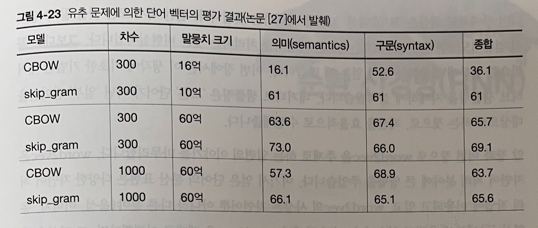
    - 위 그림은 word2vec 모델, 단어의 분산 표현의 차원 수, 말뭉치의 크기를 매개변수로 사용해 비교 실험을 수행한 결과, 각각의 결과는 위 그림 오른쪽의 세 열, 표의 의미(semantics)열은 단어의 의미를 유추하는 유추 문제으 정답율을 보여줌, 예컨데 king : queen = actor : actress 와 같이 단어의 의미를 묻는 문제, 한편 구문(syntax)열은 단어의 형태 정보를 묻는 문제로, bad : worst = good : best 같은 문제를 말함. 
    - 위 그림의 결과로부터 다음 사항을 알수 있음
        - 모델에 따라 정확도가 다름(말뭉치에 따라 적합한 모델 선택)
        - 일반적으로 말뭉치가 클수록 결과가 좋은(항상 데이터가 많은 게 좋음)
        - 단어 베거 차원 수는 적당한 크기가 좋음(너무 커도 정확도 낮아 짐)

    - 유추 문제를 이용하면 단어의 의미가 문법적인 문제를 제대로 이해하고 있는지를 어느정도 측정 가능, 그러므로 유추 문제를 정확하게 풀 수 있는 단어의 분산 표현이라면 자연어를 다루는 애플리케이션에서도 좋은 결과를 기대 할수 있음, 다만 단어의 분산 표현의 우수함이 애플리케이션에 얼마나 기어하는 지는 애플리케이션 종류와 말뭉치의 내용 등 다루는 문제에 따라 다름, 즉 유추 문제에 의한 평가가 높다고 해서 애플리케이션에서도 좋은 결과가 나온다는 보장은 없음

- 4.5 정리
    - word2vec 고속화를 주제로 CBOW 모델을 개선, 구체적으로는 Embedding 계층을 구현하고 네거티브 샘플링이라는 새로운 기법 도입, 이렇게 한 배경에는 말뭉치의 어휘 수 증가에 비례해 계산량으 증가하는 문제 때문, 핵심은 모두 대신 일부를 처리하는 것, 꼭 필요한 일부에 집중하는 것이 효율이 좋음, 네거티브 샘플링은 모든 단어가 아닌 일부 단어만을 대상으로 계산을 효율적으로 수행

- 이번 장에서 배운 내용
    - Embedding 계층은 단어의 분산 표현을 담고 있으묘, 순전파 시 지정한 단어 ID의 벡터를 추출
    - word2vec은 어휘 수의 증가에 비례하여 계산량도 증가하므로, 근사치로 계산하는 빠른 기법을 사용하는 것이 좋음
    - 네거티브 샘플링은 부정적 예를 몇 개 샘플링하는 기법, 이를 이용하면 다중 분류를 이진 분류처럼 취급 가능
    - word2vec으로 얻은 단어의 분산 표현에는 단어의 의미가 녹아들어 있으며, 비슷한 맥락에서 사용되는 단어는 단어 벡터 공간에서 가까이 위치한다
    - word3vec의 단어의 분산 표현을 이용하면 유추 문제를 벡터의 덧셈과 뺄셈으로 풀 수 있게 된다
    - word2vec은 전이 학습 측면에서 특히 중요하고, 그 단어의 분산 표현은 다양한 자연어 처리 작업에 이용